# ML Pipeline

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint

from sklearn.preprocessing import PowerTransformer
from sklearn.neighbors import LocalOutlierFactor

from sklearn.model_selection import train_test_split, StratifiedKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn import FunctionSampler
from imblearn.over_sampling import SMOTE

from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    balanced_accuracy_score,
    average_precision_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.base import clone

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("Datasets/Botswana_GAD_eGeMAPS_QBF.csv")

# Modify GAD7 binary classification
df['Anxiety_Binary'] = df['GAD7_Total'].apply(lambda x: 'Anxious' if x >= 5 else 'Non-Anxious')

# Deep copy the dataset for machine learning
ml_df = df.copy()
ml_df.drop(columns=['SessionID', 'QBF_Name', 'Sex', 'Age'], inplace=True)

# Encode anxiety categories
anxiety_category_map = {"Minimal": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
anxiety_binary_map = {"Non-Anxious": 0, "Anxious": 1}
ml_df['Anxiety_Category'] = ml_df['Anxiety_Category'].map(anxiety_category_map)
ml_df['Anxiety_Binary'] = ml_df['Anxiety_Binary'].map(anxiety_binary_map)

# Acoustic Features
metadata_cols = [
    'SessionID', 'QBF_Name', 'Sex', 'Age', 'Health', 'Health_Binary',
    'Country', 'GAD7_Total', 'Anxiety_Category', 'Anxiety_Binary'
]
acoustic_features = [col for col in ml_df.columns if col not in metadata_cols]
stddev_features = [col for col in acoustic_features if 'stddev' in col.lower()]

# Data preparation
X = ml_df[acoustic_features]
y = ml_df['Anxiety_Binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Outlier detection
def IQR_OutlierRemoval(X, y, lower_quantile=0.025, upper_quantile=0.975):
    Q1 = np.quantile(X, lower_quantile, axis=0)
    Q3 = np.quantile(X, upper_quantile, axis=0)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR
    upper_bound = Q3 + IQR

    mask_inlier_matrix = (X >= lower_bound) & (X <= upper_bound)
    mask_inlier = mask_inlier_matrix.all(axis=1)
    
    return X[mask_inlier], y[mask_inlier]

IQR_Sampler = FunctionSampler(func=IQR_OutlierRemoval, validate=False)

def LOF_OutlierRemoval(X, y, n_neighbors=20, contamination=0.05, algorithm='auto', metric='manhattan'):
    X_arr = np.asarray(X)
    y_arr = np.asarray(y)

    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        algorithm=algorithm,
        metric=metric,
        leaf_size=30,
        novelty=False)
    y_pred = lof.fit_predict(X_arr)

    mask_inliers = y_pred == 1

    return X_arr[mask_inliers], y_arr[mask_inliers]

LOF_Sampler = FunctionSampler(func=LOF_OutlierRemoval, kw_args={'contamination': 0.05}, validate=False)

# Define the pipeline
pipeline = ImbPipeline([
    ("yjpt", PowerTransformer(method='yeo-johnson', standardize=True)),
    ("outlier_removal", LOF_Sampler),
    ("oversampling", SMOTE(k_neighbors=5, random_state=42)),
    ("clf", SVC(random_state=42))
])

# Define the parameter grid
param_grid_rs = {
    'oversampling__k_neighbors': randint(3, 10),
    'clf__C': loguniform(1e-1, 1e6),
    'clf__gamma': loguniform(1e-5, 1e1),
    'clf__kernel': ['rbf']
}

param_grid_gs = {
    'oversampling__k_neighbors': [3, 5, 7, 9],
    'clf__C': [1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6],
    'clf__gamma': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1],
    'clf__kernel': ['rbf']
}

# Initialize the stratified K-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define multiple scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy',
    'average_precision': 'average_precision',
}

# Initialize RandomizedSearchCV
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid_rs,
    n_iter=1_000,
    scoring=scoring,
    refit='roc_auc',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=2,
    random_state=42
)

gs = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_gs,
    scoring=scoring,
    refit='roc_auc',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

In [3]:
# Fit the model
gs.fit(X_train, y_train)

Fitting 5 folds for each of 252 candidates, totalling 1260 fits


[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=5; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=3; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=5; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=3; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=5; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=9; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=0.0001, clf__kernel=rbf, oversampling__k_neighbors=9; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=9; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rbf, oversampling__k_neighbors=7; total time=   0.1s
[CV] END clf__C=0.01, clf__gamma=1e-05, clf__kernel=rb

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('yjpt', PowerTransformer()),
                                       ('outlier_removal',
                                        FunctionSampler(func=<function LOF_OutlierRemoval at 0x153fe108f600>,
                                                        kw_args={'contamination': 0.05},
                                                        validate=False)),
                                       ('oversampling', SMOTE(random_state=42)),
                                       ('clf', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0,
                                    10000.0, 100000.0, 1000000.0],
                         'clf__gamma': [1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0,
                                        10.0],
                         'clf__kernel': ['rbf'],
                         'oversampling__k_neighbors': [3, 5, 7, 9]},
             refit='roc_auc', return_train_score=True,
             scoring={'average_precision': 'average_precision',
                      'balanced_accuracy': 'balanced_accuracy',
                      'roc_auc': 'roc_auc'},
             verbose=2)

In [4]:
# Fit the model
rs.fit(X_train, y_train)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
[CV] END clf__C=28697.03331512518, clf__gamma=0.0381154408865306, clf__kernel=rbf, oversampling__k_neighbors=4; total time=   0.1s
[CV] END clf__C=28697.03331512518, clf__gamma=0.0381154408865306, clf__kernel=rbf, oversampling__k_neighbors=4; total time=   0.1s
[CV] END clf__C=41.858227295469725, clf__gamma=5.061576888752303, clf__kernel=rbf, oversampling__k_neighbors=5; total time=   0.1s
[CV] END clf__C=41.858227295469725, clf__gamma=5.061576888752303, clf__kernel=rbf, oversampling__k_neighbors=5; total time=   0.1s
[CV] END clf__C=41.858227295469725, clf__gamma=5.061576888752303, clf__kernel=rbf, oversampling__k_neighbors=5; total time=   0.1s
[CV] END clf__C=28697.03331512518, clf__gamma=0.0381154408865306, clf__kernel=rbf, oversampling__k_neighbors=4; total time=   0.1s
[CV] END clf__C=41.858227295469725, clf__gamma=5.061576888752303, clf__kernel=rbf, oversampling__k_neighbors=5; total time=   0.1s
[CV] END clf__C=41

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('yjpt', PowerTransformer()),
                                             ('outlier_removal',
                                              FunctionSampler(func=<function LOF_OutlierRemoval at 0x153fe108f600>,
                                                              kw_args={'contamination': 0.05},
                                                              validate=False)),
                                             ('oversampling',
                                              SMOTE(random_state=42)),
                                             ('clf', SVC(random_state=42))]),
                   n_iter=1000, n...
                                        'clf__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x153fe1395710>,
                                        'clf__kernel': ['rbf'],
                                        'oversampling__k_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x153fe1363c90>},
                   random_state=42, refit='roc_auc', return_train_score=True,
                   scoring={'average_precision': 'average_precision',
                            'balanced_accuracy': 'balanced_accuracy',
                            'roc_auc': 'roc_auc'},
                   verbose=2)

In [5]:
# Best parameters and score
print("Best Parameters:", gs.best_params_)
print(f"Best ROC AUC Score: {gs.best_score_:.4f}")
cv_results_gs = pd.DataFrame(gs.cv_results_)
cv_results_gs = cv_results_gs.sort_values(by=["rank_test_roc_auc"], ascending=True, ignore_index=False)

# Evaluate on the test set
best_model = gs.best_estimator_
y_test_pred = best_model.predict(X_test)
y_test_scores = best_model.decision_function(X_test)
print(classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_test_scores):.2f}")
print(f"Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.2f}")
print(f"Test Average Precision: {average_precision_score(y_test, y_test_scores):.2f}")

Best Parameters: {'clf__C': 0.01, 'clf__gamma': 0.001, 'clf__kernel': 'rbf', 'oversampling__k_neighbors': 7}
Best ROC AUC Score: 0.5458
              precision    recall  f1-score   support

           0       0.52      0.46      0.49        28
           1       0.59      0.65      0.62        34

    accuracy                           0.56        62
   macro avg       0.56      0.56      0.56        62
weighted avg       0.56      0.56      0.56        62

Test ROC AUC Score: 0.54
Test Balanced Accuracy: 0.56
Test Average Precision: 0.58


In [6]:
# Best parameters and score
print("Best Parameters:", rs.best_params_)
print(f"Best ROC AUC Score: {rs.best_score_:.4f}")
cv_results_rs = pd.DataFrame(rs.cv_results_)
cv_results_rs = cv_results_rs.sort_values(by=["rank_test_roc_auc"], ascending=True, ignore_index=False)

# Evaluate on the test set
best_model = rs.best_estimator_
y_test_pred = best_model.predict(X_test)
y_test_scores = best_model.decision_function(X_test)
print(classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_test_scores):.2f}")
print(f"Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.2f}")
print(f"Test Average Precision: {average_precision_score(y_test, y_test_scores):.2f}")

Best Parameters: {'clf__C': np.float64(1.174935360217671), 'clf__gamma': np.float64(0.0002990517652413063), 'clf__kernel': 'rbf', 'oversampling__k_neighbors': 6}
Best ROC AUC Score: 0.5486
              precision    recall  f1-score   support

           0       0.52      0.46      0.49        28
           1       0.59      0.65      0.62        34

    accuracy                           0.56        62
   macro avg       0.56      0.56      0.56        62
weighted avg       0.56      0.56      0.56        62

Test ROC AUC Score: 0.53
Test Balanced Accuracy: 0.56
Test Average Precision: 0.57


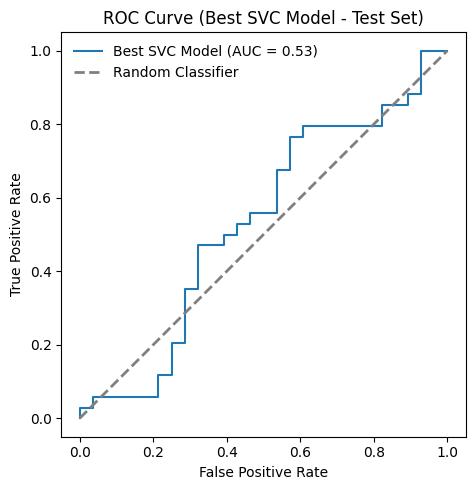

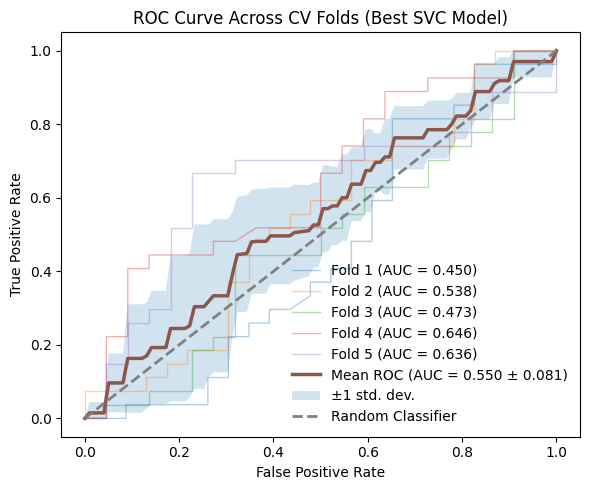

In [7]:
# Plot the ROC curve for the best model
fig, ax = plt.subplots(figsize=(8, 5))
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    name='Best SVC Model',
    ax=ax
)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="ROC Curve (Best SVC Model - Test Set)"
)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Plot the ROC across CV folds for the best model
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Plot ROC for each fold
fig, ax = plt.subplots(figsize=(6, 5))
for fold_idx, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    temp_model = clone(best_model)
    temp_model.fit(X_tr, y_tr)

    y_score = temp_model.decision_function(X_va)
    
    fpr, tpr, _ = roc_curve(y_va, y_score)
    fold_auc = auc(fpr, tpr)
    aucs.append(fold_auc)

    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

    plt.plot(fpr, tpr, lw=1, alpha=0.35, label=f"Fold {fold_idx} (AUC = {fold_auc:.3f})")

# Plot mean ROC curve
tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)
mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
plt.plot(
    mean_fpr,
    mean_tpr,
    lw=2.5,
    label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})"
)

tpr_lower = np.clip(mean_tpr - std_tpr, 0, 1)
tpr_upper = np.clip(mean_tpr + std_tpr, 0, 1)
plt.fill_between(mean_fpr, tpr_lower, tpr_upper, alpha=0.2, label="±1 std. dev.")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="ROC Curve Across CV Folds (Best SVC Model)"
)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

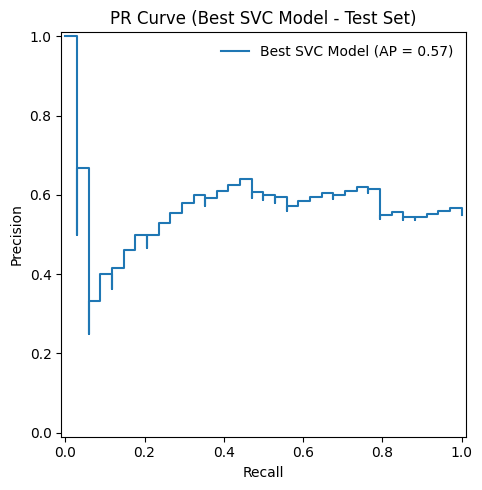

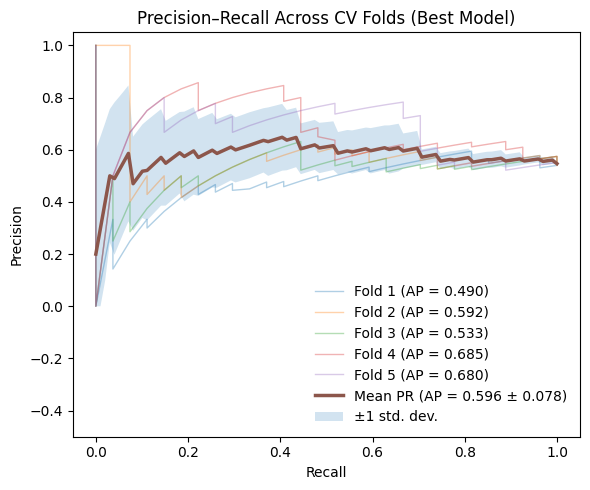

In [8]:
# Plot the PR curve for the best model on the test set
y_test_scores = best_model.decision_function(X_test)
avg_precision = average_precision_score(y_test, y_test_scores)

fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_scores,
    name=f"Best SVC Model",
    ax=ax
)

ax.set(
    xlabel="Recall",
    ylabel="Precision",
    title="PR Curve (Best SVC Model - Test Set)"
)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Plot the PR across CV folds for the best model
mean_recall = np.linspace(0, 1, 100)
precisions = []
aps = []

fig, ax = plt.subplots(figsize=(6, 5))

for fold_idx, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    temp_model = clone(best_model)
    temp_model.fit(X_tr, y_tr)

    y_score = temp_model.decision_function(X_va)

    precision, recall, _ = precision_recall_curve(y_va, y_score)
    ap = average_precision_score(y_va, y_score)
    aps.append(ap)
    
    precision_interp = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(precision_interp)

    ax.plot(
        recall,
        precision,
        lw=1,
        alpha=0.35,
        label=f"Fold {fold_idx} (AP = {ap:.3f})"
    )

# Plot mean PR curve
precisions = np.array(precisions)
mean_precision = precisions.mean(axis=0)
std_precision = precisions.std(axis=0)

mean_ap = np.mean(aps)
std_ap = np.std(aps)

ax.plot(
    mean_recall,
    mean_precision,
    lw=2.5,
    label=f"Mean PR (AP = {mean_ap:.3f} ± {std_ap:.3f})"
)

ax.fill_between(
    mean_recall,
    np.clip(mean_precision - std_precision, 0, 1),
    np.clip(mean_precision + std_precision, 0, 1),
    alpha=0.2,
    label="±1 std. dev."
)

ax.set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision–Recall Across CV Folds (Best Model)",
    xlim=[-0.05, 1.05],
    ylim=[-0.5, 1.05]
)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()